# EvidenceLab #05 | When One Number Does Not Belong
## Outlier detection, anomaly investigation, and what to do next
**An unusual value is a question to investigate, not an instruction to delete.**

Dr. Amobi Andrew Onovo, PhD, MPH · Epidemiology | Data Science | AI for Global Health

**EvidenceLab | See it. Understand it. Run it.**

### Imagine this...
Your organization normally records around **1,000 to 1,400 enrollments each month**. Then one month reports:

## 12,500

What should you do?

- **A.** Delete it
- **B.** Replace it
- **C.** Ignore it
- **D.** Investigate it

> **EvidenceLab answer: Investigate it first.**

The number alone cannot tell us whether 12,500 represents a **data-entry error**, a **rare but valid event**, or an **important change in the underlying process**. In this fictional scenario, the usual range is descriptive, not a rule that makes every value outside it wrong.

**Detect it. Verify it. Understand it. Then decide.**

### Run the lesson
Choose **Runtime → Run all → read from top to bottom**. All data are synthetic and generated here. No dataset upload, API key, local input file, manual answer or code edit is required. The notebook produces charts, result tables and CSV exports automatically in the relative `outputs/` folder. NumPy, pandas and Matplotlib are available in a standard Python Colab runtime. The questions are reflection prompts; execution never waits for an answer.

### Your learning roadmap
**START**  
↓  
**1 | Meet the data**  
↓  
**2 | See the distribution**  
↓  
**3 | Detect unusual values**  
↓  
**4 | Verify what happened**  
↓  
**5 | Understand the context**  
↓  
**6 | Decide what to do**  
↓  
**7 | Stress-test the decision**  
↓  
**8 | Monitor for early-warning signals**  
↓  
**FINISH**

We revisit these stages as the evidence develops. The full EvidenceLab workflow remains:

**DETECT → VERIFY → CONTEXTUALIZE → QUANTIFY → DECIDE → STRESS-TEST → MONITOR**

## 1 | A number that deserves a question
First, use a separate, smaller synthetic programme example: **12 monthly enrolment counts**, with **850 in July**. This is the example in the infographic, not the later 36-month dataset containing 12,500. The smaller example makes the screening calculation visible before we investigate the main scenario.

### Read the middle before judging the extremes
A **distribution** describes how the observed values are spread out. Sort the values from smallest to largest to understand its five-number summary:

| Summary | Plain-language meaning |
|---|---|
| Minimum | Smallest observed value |
| Q1 | 25th percentile: roughly a quarter of observations are at or below it |
| Median | Middle value; with an even number of observations, the average of the two middle values |
| Q3 | 75th percentile: roughly three quarters are at or below it |
| Maximum | Largest observed value |

With ties or a small sample, these percentages need not hold exactly. This notebook uses **linear interpolation** between sorted observations, so a quartile need not equal an observed count.

**IQR = Q3 − Q1.** The interquartile range describes the **width of the middle 50%** of observations.

### IQR screening, step by step
1. Calculate **Q1**, the 25th percentile.
2. Calculate **Q3**, the 75th percentile.
3. Calculate **IQR = Q3 − Q1**.
4. Calculate the screening fences: **lower = Q1 − 1.5 × IQR**; **upper = Q3 + 1.5 × IQR**.
5. Flag values strictly below the lower fence or strictly above the upper fence.

> **Outside the fence = INVESTIGATE**  
> **Outside the fence ≠ DELETE**

The **1.5 × IQR** multiplier is a conventional screening rule, not a universal definition of erroneous data. A fence is a threshold for attention, not a limit on what can happen.


**What are we doing?** Calculate a screening range for the 12-month example.

**Why does it matter?** We need a transparent way to notice unusual values without deciding their cause.

**What should you look for?** Q1, Q3, the width between them, and the month outside the fences.


In [1]:
from pathlib import Path
import json, sys, platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 20261002
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'font.size':12, 'axes.titlesize':15, 'axes.labelsize':12,
                     'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
NAVY, TEAL, ORANGE, RED = '#12365A', '#008878', '#E58A23', '#CC3344'
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
enrolments = pd.Series([280,340,375,395,345,340,850,340,295,240,275,240], index=months)
q1, q3 = enrolments.quantile([.25,.75], interpolation='linear')
iqr = q3-q1
lower, upper = q1-1.5*iqr, q3+1.5*iqr
small_flags = (enrolments<lower)|(enrolments>upper)
print(f'Q1={q1:.2f}; Q3={q3:.2f}; IQR={iqr:.2f} enrolments')
print(f'Fences: {lower:.2f} to {upper:.2f} enrolments')
print('Flagged months:', ', '.join(enrolments.index[small_flags]))


Q1=278.75; Q3=352.50; IQR=73.75 enrolments
Fences: 168.12 to 463.12 enrolments
Flagged months: Jul


### What did we learn?
Q1 is **278.75**, Q3 is **352.50**, and IQR is **73.75** enrolments. The fences are **168.125** and **463.125**; July alone is flagged.

The upper fence is a screening threshold, not a maximum possible enrolment. July crosses it. A campaign, a reporting change or an entry error could each explain the same point. We need records to distinguish them.

### See the flag in context
The line chart preserves time order. The fence shows the distributional rule. Watch how one point attracts attention without revealing its cause.


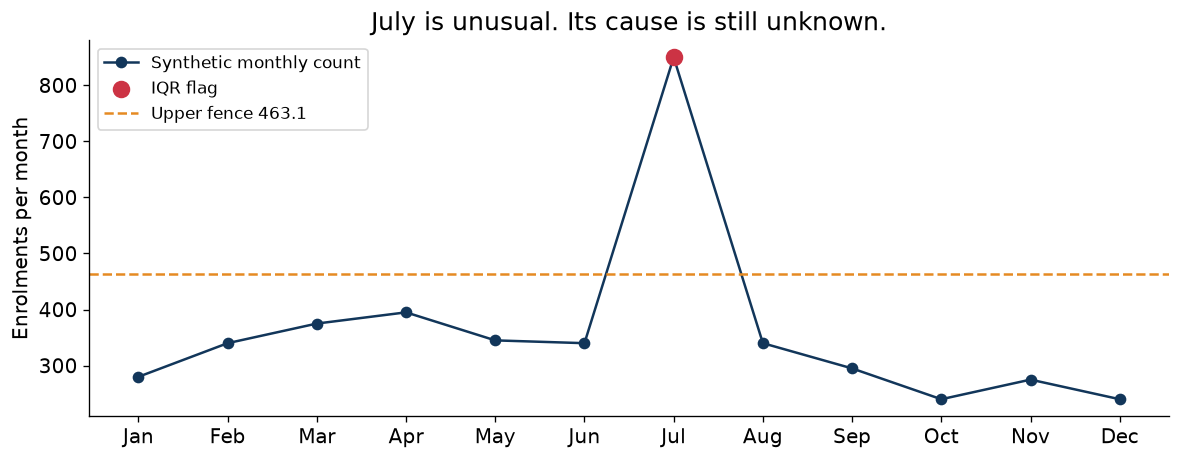

In [2]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(months, enrolments, '-o', color=NAVY, label='Synthetic monthly count')
ax.scatter(np.where(small_flags)[0], enrolments[small_flags], s=90, color=RED, zorder=3, label='IQR flag')
ax.axhline(upper, color=ORANGE, linestyle='--', label=f'Upper fence {upper:.1f}')
ax.set(ylabel='Enrolments per month', title='July is unusual. Its cause is still unknown.')
ax.legend(fontsize=10, loc='upper left'); fig.tight_layout()
fig.savefig(OUT/'01_enrolment_example.png'); plt.show()


## 2 | Outlier, anomaly, or error?
An **outlier** is unusually distant from a distribution under a stated rule. A **contextual anomaly** is unusual relative to expected behaviour, such as a seasonal pattern or subgroup. A **collective anomaly** is a sequence that is unusual together, even when individual points seem ordinary. A **multivariate anomaly** is an unusual combination, such as normal sales with almost no customers; this lesson does not fit a multivariate detector.

An **error** is an incorrect record. A **rare but valid value** is real. An **early-warning signal** is a reason to investigate a possible meaningful change; a flag does not prove its cause.

### OUTLIER versus ANOMALY
| OUTLIER | ANOMALY |
|---|---|
| Unusual relative to a distribution | Unusual relative to expected behaviour |
| “How extreme is this value?” | “Is this expected here and now?” |
| IQR can help detect it | Time/context-aware methods can help detect it |
| May be an error or a valid extreme | May represent an early-warning signal |

These terms overlap in practice; here they help separate two questions. A value near **1,700** may not be globally extreme, yet may be surprising in a month expected to be near **1,200**. We will inspect the actual September 2025 result after fitting the existing monitoring model; these are rounded teaching values, not a second dataset or model.

### Where our main data come from
We simulate 36 consecutive months, January 2023–December 2025, for one fictional programme. Counts have a gradual trend, annual seasonality and random variation. There are three event types: a transcription error, a documented campaign, and six months of unexplained elevated activity. All source notes are invented teaching evidence, not real programme records.

| Field | Meaning and role |
|---|---|
| date | One row per calendar month |
| observed | Recorded monthly count; includes one deliberate entry error |
| source_verified | Source value available only for the confirmed error |
| reason / action | Investigation metadata, revealed after detection |
| expected_design | Known simulation baseline; never used as an observed predictor |

We also simulate 200 positive transaction amounts in arbitrary currency units. This skewed variable illustrates valid tails, rather than known errors. Neither dataset estimates a real population rate. For real rates, exposure denominators and changes in coverage must also be investigated.


**What are we doing?** Meet the 36-month programme dataset and a separate transaction dataset.

**Why does it matter?** The meaning of a value depends on what was measured, when, and how.

**What should you look for?** One row per month, units, completeness, and the five-number summary.


In [3]:
rng = np.random.default_rng(SEED)
t = np.arange(36)
expected_design = 1000 + 10*t + 110*np.sin(2*np.pi*t/12)
true_counts = np.rint(expected_design + rng.normal(0,35,36)).astype(int)
true_counts[14] = 1250
true_counts[23] += 850
true_counts[30:] += 420
observed = true_counts.copy()
observed[14] = 12500
raw = pd.DataFrame({'date':pd.date_range('2023-01-01',periods=36,freq='MS'),
                    'observed':observed, 'expected_design':expected_design})
evidence = pd.DataFrame({'date':raw.date, 'source_verified':np.nan,
                        'reason':'Routine month; no specific incident documented',
                        'action':'Retain; routine monitoring'})
evidence.loc[14,['source_verified','reason','action']] = [1250,'Confirmed transcription: 12,500 entered instead of 1,250','Correct to 1,250; retain original']
evidence.loc[23,['reason','action']] = ['Documented campaign with verified additional enrolments','Keep; model campaign separately if needed']
evidence.loc[30:,['reason','action']] = ['Unexplained sustained increase; cause unconfirmed','Keep; verify coverage and investigate; monitor']
transactions = pd.DataFrame({'id':np.arange(1,201), 'amount':rng.lognormal(mean=3.7,sigma=.65,size=200)})
raw_snapshot = raw.copy(deep=True)
display(raw[['date','observed']].head())
print('Monthly dtypes:', raw[['date','observed']].dtypes.astype(str).to_dict())
print('Missing counts:', raw.observed.isna().sum(), '| duplicate months:', raw.date.duplicated().sum())
five_number = pd.DataFrame({'monthly_recorded':raw.observed.quantile([0,.25,.5,.75,1]),
                           'transaction_amount':transactions.amount.quantile([0,.25,.5,.75,1])})
five_number.index = ['minimum','Q1','median','Q3','maximum']
display(five_number.round(2))


,date,observed
0,2023-01-01,992
1,2023-02-01,1098
2,2023-03-01,1137
3,2023-04-01,1128
4,2023-05-01,1101


Monthly dtypes: {'date': 'datetime64[us]', 'observed': 'int64'}
Missing counts: 0 | duplicate months: 0


,monthly_recorded,transaction_amount
minimum,890.00,8.41
Q1,1089.50,24.94
median,1176.50,40.40
Q3,1416.75,61.46
maximum,12500.00,192.17


### What did we learn?
All 36 months are present. A complete table can still contain a serious error. The maximum deserves review; the summary alone cannot explain it.

## 3 | Four views before any treatment
The histogram shows shape; the boxplot locates the middle half and distant points; the scatterplot reveals individual transactions; the monthly line chart preserves sequence. Boxplot whiskers end at the most extreme observed values within the fences, not necessarily at the fences themselves.


**What are we doing?** View shape, individual values and time order before treatment.

**Why does it matter?** A single graph cannot reveal every kind of unusual behaviour.

**What should you look for?** The valid right tail and how 12,500 stretches the monthly chart.


### Read a boxplot before using one
The box extends from **Q1 to Q3**; the line inside is the **median**. Its length represents the **IQR**. In this 1.5 × IQR boxplot, the **whiskers** reach the smallest and largest observed values still within the fences. They are not necessarily the minimum and maximum of the full dataset, nor the fence positions themselves.

The anatomy visual uses the same 12-month example as the opening calculation. The four-view analysis below it uses the main monthly and transaction datasets.


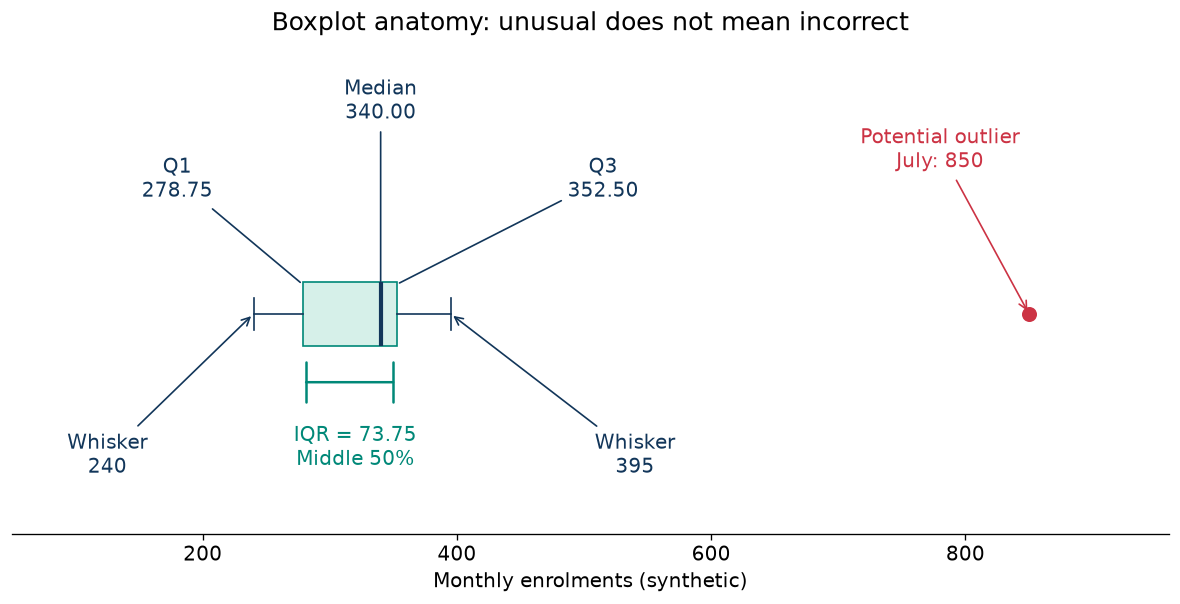

In [4]:
def draw_boxplot_anatomy():
    # A teaching visual of the existing 12-month example; no new random data.
    with plt.rc_context({'font.size': 12}):
        anatomy_fig, anatomy_ax = plt.subplots(figsize=(10, 5.2))
        direction = {'orientation':'horizontal'} if tuple(map(int,matplotlib.__version__.split('.')[:2])) >= (3,10) else {'vert':False}
        anatomy_ax.boxplot(enrolments.to_numpy(), positions=[1], widths=.26,
            patch_artist=True, boxprops={'facecolor':'#D6F0E9','edgecolor':TEAL},
            medianprops={'color':NAVY,'linewidth':2.5},
            whiskerprops={'color':NAVY}, capprops={'color':NAVY},
            flierprops={'marker':'o','markerfacecolor':RED,'markeredgecolor':RED,'markersize':8}, **direction)
        a_q1,a_med,a_q3=np.quantile(enrolments,[.25,.5,.75],method='linear')
        a_iqr=a_q3-a_q1
        a_low,a_high=a_q1-1.5*a_iqr,a_q3+1.5*a_iqr
        inside=enrolments[(enrolments>=a_low)&(enrolments<=a_high)]
        for label,value,xytext in [('Q1',a_q1,(180,1.55)),('Median',a_med,(340,1.87)),('Q3',a_q3,(515,1.55))]:
            anatomy_ax.annotate(f'{label}\n{value:.2f}',xy=(value,1.12),xytext=xytext,
                ha='center',va='center',color=NAVY,arrowprops={'arrowstyle':'-','color':NAVY})
        anatomy_ax.annotate('',xy=(a_q1,.72),xytext=(a_q3,.72),arrowprops={'arrowstyle':'|-|','color':TEAL,'linewidth':1.5})
        anatomy_ax.text(320,.55,f'IQR = {a_iqr:.2f}\nMiddle 50%',ha='center',va='top',color=TEAL)
        for value,tx in [(inside.min(),125),(inside.max(),540)]:
            anatomy_ax.annotate(f'Whisker\n{value:g}',xy=(value,1),xytext=(tx,.42),ha='center',va='center',
                color=NAVY,arrowprops={'arrowstyle':'->','color':NAVY})
        anatomy_ax.annotate('Potential outlier\nJuly: 850',xy=(850,1),xytext=(780,1.6),ha='center',color=RED,
            arrowprops={'arrowstyle':'->','color':RED})
        anatomy_ax.set(xlim=(50,960),ylim=(.1,2.12),yticks=[],xlabel='Monthly enrolments (synthetic)',
            title='Boxplot anatomy: unusual does not mean incorrect')
        anatomy_ax.spines['left'].set_visible(False)
        anatomy_fig.tight_layout()
        anatomy_fig.savefig(OUT/'07_boxplot_anatomy.png')
        plt.show()
draw_boxplot_anatomy()


> **A point beyond the whisker is unusual under this statistical rule. It does not tell us why it is unusual.**

July's 850 is beyond the upper whisker; the whisker ends at 395, while the upper fence is 463.125. **The maximum and the whisker endpoint are different.** We still have no source evidence explaining July.


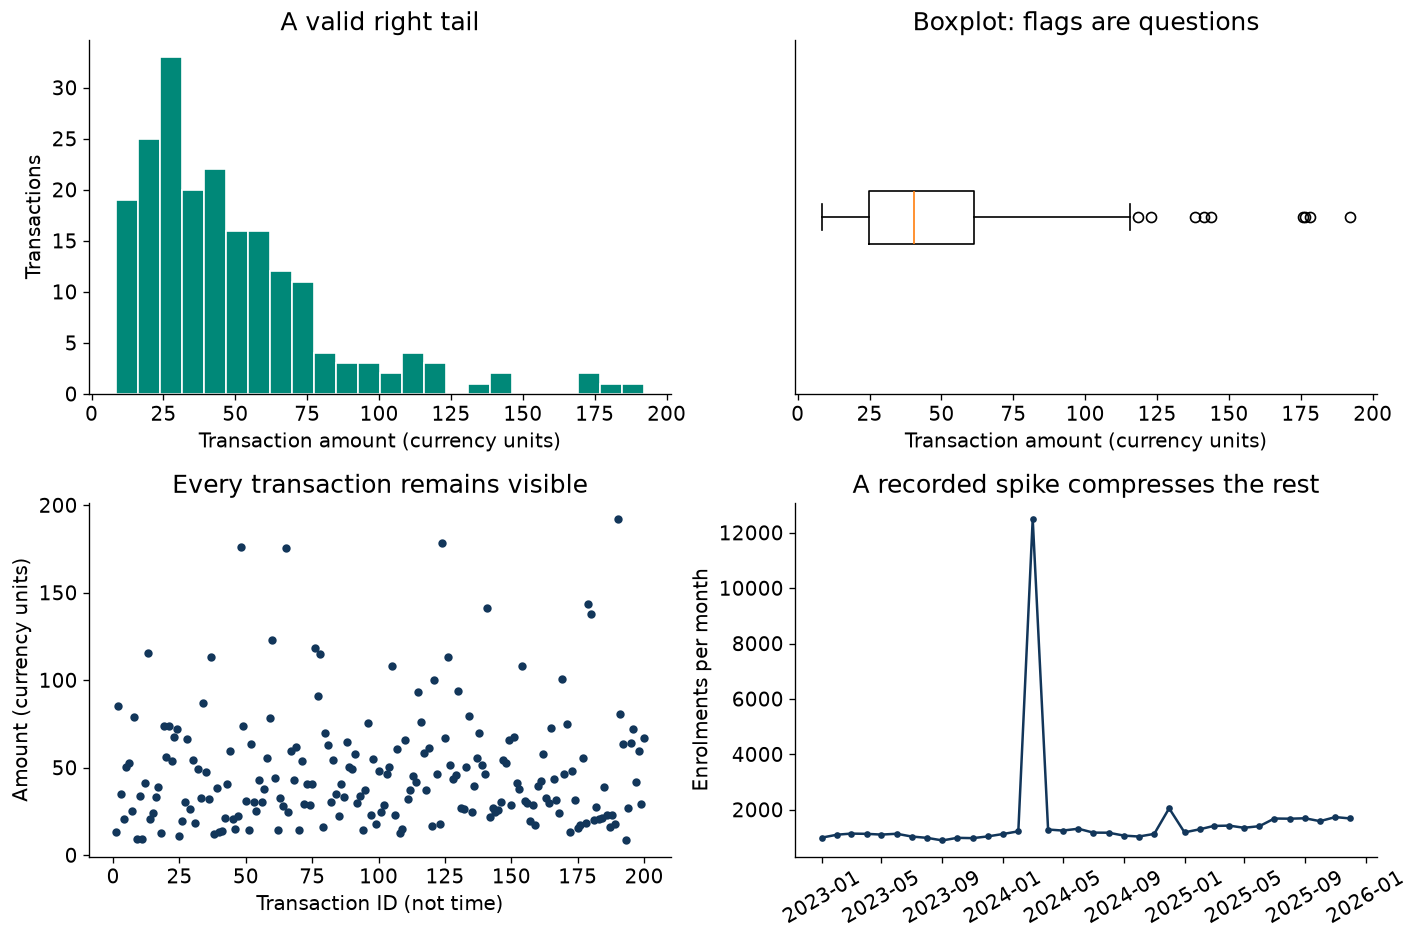

In [5]:
fig, axes = plt.subplots(2,2,figsize=(12,8))
axes[0,0].hist(transactions.amount,bins=24,color=TEAL,edgecolor='white')
axes[0,0].set(title='A valid right tail',xlabel='Transaction amount (currency units)',ylabel='Transactions')
axes[0,1].boxplot(transactions.amount,**({'orientation':'horizontal'} if tuple(map(int,matplotlib.__version__.split('.')[:2]))>=(3,10) else {'vert':False}))
axes[0,1].set(title='Boxplot: flags are questions',xlabel='Transaction amount (currency units)',yticks=[])
axes[1,0].scatter(transactions.id,transactions.amount,color=NAVY,s=16)
axes[1,0].set(title='Every transaction remains visible',xlabel='Transaction ID (not time)',ylabel='Amount (currency units)')
axes[1,1].plot(raw.date,raw.observed,'-o',color=NAVY,markersize=3)
axes[1,1].set(title='A recorded spike compresses the rest',ylabel='Enrolments per month')
axes[1,1].tick_params(axis='x',rotation=30)
fig.tight_layout(); fig.savefig(OUT/'02_four_views.png'); plt.show()


### What did we learn?
The transaction distribution is skewed by design. Large values may be valid even if a symmetric screening convention flags them. The recorded monthly spike also hides smaller changes by stretching the vertical scale. We will revisit the series after checking its source.

## 4 | Calculate IQR fences and preserve the flags
**IQR = Q3 − Q1. Lower fence = Q1 − 1.5 × IQR. Upper fence = Q3 + 1.5 × IQR.**

Q1 and Q3 are the 25th and 75th percentiles. We use linear interpolation throughout; small samples may give different quartiles under another convention. A value equal to a fence is not flagged here. The multiplier is a screening choice, not a biological or operational law.

### CHECK → CLEAN → VERIFY → ANALYZE
Check types, units, coverage, missing values and duplicate keys first. Correct only when source evidence supports correction. Preserve raw records and record each change. Verify that corrections did what was intended, then analyse. Missing values are not zero counts. In an uploaded real dataset, stop and resolve duplicate months or missing observations before applying this example's complete-series methods.

### Under the hood
These small functions centralize the screening rules. They reject missing or infinite inputs so that missing data cannot disappear silently. Zero IQR or MAD can occur with ties; an IQR flag then needs particular care, while an undefined robust z-score remains missing.


**What are we doing?** Apply the same IQR steps to all 36 recorded months.

**Why does it matter?** Keeping flags separate from corrections preserves the distinction between detection and evidence.

**What should you look for?** The numerical fences and the rows flagged, not an instruction to remove them.


In [6]:
def checked(x):
    a = np.asarray(x,dtype=float)
    if a.ndim != 1 or len(a)<4 or not np.isfinite(a).all():
        raise ValueError('Use at least four finite observations; resolve missingness explicitly.')
    return a

def iqr_screen(x,k=1.5):
    a = checked(x)
    q1,q3 = np.quantile(a,[.25,.75],method='linear')
    width = q3-q1
    lo,hi = q1-k*width,q3+k*width
    return (a<lo)|(a>hi), {'Q1':q1,'Q3':q3,'IQR':width,'lower':lo,'upper':hi,'k':k}

def robust_z(x):
    a = checked(x)
    med = np.median(a)
    mad = np.median(np.abs(a-med))
    return np.full(len(a),np.nan) if mad==0 else .67448975*(a-med)/mad

flags, fences = iqr_screen(raw.observed)
flag_table = raw[['date','observed']].assign(iqr_flag=flags)
display(pd.DataFrame([fences]).round(2))
display(flag_table.loc[flag_table.iqr_flag])
tx_flags, tx_fences = iqr_screen(transactions.amount)
print(f'{tx_flags.sum()} of {len(transactions)} synthetic transactions cross IQR fences; none is a known error.')


,Q1,Q3,IQR,lower,upper,k
0,1089.5,1416.75,327.25,598.62,1907.62,1.5


,date,observed,iqr_flag
14,2024-03-01,12500,True
23,2024-12-01,2050,True


9 of 200 synthetic transactions cross IQR fences; none is a known error.


### What did we learn?
These are **whole-distribution** flags across 36 months. Pooling months ignores their order and changing baseline, so an unflagged late month can still be anomalous. Skewness, heavy tails, small samples, mixtures and subgroup differences all affect what the rule flags. Investigate a subgroup before deciding that a pooled threshold is appropriate.

## 5 | Go deeper: median, MAD and masking
Before any formula: extreme observations can pull the mean toward themselves and inflate the standard deviation. The median and MAD are designed to be less sensitive to such extremes.

To understand **MAD**, find the middle value, measure how far each observation is from it (ignoring direction), then take the middle of those distances. This is a typical distance from the median, not the average distance from the mean.

The median is the middle value. The **median absolute deviation (MAD)** is the median distance from that middle. Unlike the standard deviation, it is less affected by one huge observation.

**Modified z = 0.67449 × (value − median) / MAD.** The factor matches the standard-deviation scale under a normal distribution. A conventional absolute threshold of 3.5 can screen for candidates; it does not assign a probability that a record is wrong. The ordinary z-score uses the mean and sample standard deviation. An extreme record can inflate both and hide other unusual records, called masking.

Here both scores use the same recorded months. Neither accounts for seasonal context.


**What are we doing?** Compare ordinary mean/SD scores with median/MAD scores.

**Why does it matter?** Extreme observations can pull the mean and inflate the standard deviation; robust summaries are less sensitive to them.

**What should you look for?** Whether the very large recorded value makes other changes look smaller on the ordinary z-score scale.


In [7]:
scores = flag_table.copy()
scores['ordinary_z'] = (raw.observed-raw.observed.mean())/raw.observed.std(ddof=1)
scores['modified_z'] = robust_z(raw.observed)
display(scores.loc[[14,23,30,31,32,33,34,35]].round({'observed':2,'ordinary_z':2,'modified_z':2}))
robust_comparison = pd.DataFrame({'statistic':['Mean','Median','Sample SD','MAD'],
    'recorded':[raw.observed.mean(),raw.observed.median(),raw.observed.std(ddof=1),
                np.median(np.abs(raw.observed-raw.observed.median()))]})
display(robust_comparison.round(2))


,date,observed,iqr_flag,ordinary_z,modified_z
14,2024-03-01,12500,True,5.77,52.49
23,2024-12-01,2050,True,0.25,4.05
30,2025-07-01,1681,False,0.05,2.34
31,2025-08-01,1675,False,0.05,2.31
32,2025-09-01,1690,False,0.06,2.38
33,2025-10-01,1586,False,0.00,1.90
34,2025-11-01,1733,False,0.08,2.58
35,2025-12-01,1683,False,0.05,2.35


,statistic,recorded
0,Mean,1580.36
1,Median,1176.50
2,Sample SD,1891.29
3,MAD,145.50


### What did we learn?
The entry error is obvious by either score. Other changes can be less visible on the inflated ordinary z scale. Robust does not mean context-aware: a global median can also miss a sustained change or flag a perfectly normal seasonal peak.

## 6 | Verify the story before changing the data
Now open the fictional source log. In practice, check the original form/system, units, dates, coding, duplicate records, measurement conditions, reporting coverage and intervention dates. Metadata is **investigation evidence**, not input to the initial flagging rule.

The campaign's cause is stipulated in this simulation. An observational time series alone would not establish that causal attribution. The sustained increase has an intentionally unknown cause.


**What are we doing?** Compare flagged records with fictional source documentation.

**Why does it matter?** Only independent source evidence can justify the verified correction in this example.

**What should you look for?** The original 12,500, the verified 1,250, the reason and the recorded action.


In [8]:
investigation = flag_table.merge(evidence,on='date',validate='one_to_one')
display(investigation.loc[(investigation.iqr_flag)|(investigation.index==23)|(investigation.index>=30)])
analysis = raw.copy(deep=True)
analysis['corrected'] = analysis.observed.astype(float)
has_source = evidence.source_verified.notna()
analysis.loc[has_source,'corrected'] = evidence.loc[has_source,'source_verified']
treatment_log = investigation.loc[has_source,['date','observed','source_verified','reason','action']].copy()
treatment_log['decision_basis'] = 'Fictional source record confirms transcription error'
assert analysis.loc[14,'corrected']==1250
assert (analysis.observed==raw_snapshot.observed).all()
assert (analysis.corrected!=analysis.observed).sum()==1
display(treatment_log)


,date,observed,iqr_flag,source_verified,reason,action
14,2024-03-01,12500,True,1250.0,"Confirmed transcription: 12,500 entered instea...","Correct to 1,250; retain original"
23,2024-12-01,2050,True,NaN,Documented campaign with verified additional e...,Keep; model campaign separately if needed
30,2025-07-01,1681,False,NaN,Unexplained sustained increase; cause unconfirmed,Keep; verify coverage and investigate; monitor
31,2025-08-01,1675,False,NaN,Unexplained sustained increase; cause unconfirmed,Keep; verify coverage and investigate; monitor
32,2025-09-01,1690,False,NaN,Unexplained sustained increase; cause unconfirmed,Keep; verify coverage and investigate; monitor
33,2025-10-01,1586,False,NaN,Unexplained sustained increase; cause unconfirmed,Keep; verify coverage and investigate; monitor
34,2025-11-01,1733,False,NaN,Unexplained sustained increase; cause unconfirmed,Keep; verify coverage and investigate; monitor
35,2025-12-01,1683,False,NaN,Unexplained sustained increase; cause unconfirmed,Keep; verify coverage and investigate; monitor


,date,observed,source_verified,reason,action,decision_basis
14,2024-03-01,12500,1250.0,"Confirmed transcription: 12,500 entered instea...","Correct to 1,250; retain original",Fictional source record confirms transcription...


### Three events, three responses
| Observation | Statistical appearance | Investigation | Action |
|---|---|---|---|
| 12,500 | Extreme; global IQR flag | Source confirms 1,250 | Correct; preserve the original |
| Campaign: 2,050 | Extreme; global IQR flag | Documented valid event | Keep; add context |
| Later sustained increase | Not a global IQR outlier in this dataset | Unexplained time/context change | Investigate + monitor |

**Same statistical alarm. Different explanation. Different action.** This contrast applies directly to the two flagged spikes. The later sustained increase requires a different, time-aware alarm; global IQR misses it.

The correction log preserves the **original value**, **verified value**, **reason**, **action**, **observation date**, and explicit **fictional source indicator**. Data cleaning should be auditable. Correction should not mean erasing the history of what was observed.


### What did we learn?
Only one value was corrected. The campaign and the sustained increase remain. A statistical rule did not authorize this change; a verified source record did.

## 7 | Compare treatments without changing the question silently
**Different treatments can produce different answers.**

### One possible treatment: Winsorization
Winsorization replaces values beyond chosen cut points with boundary values, limiting their influence while retaining rows.

> **Winsorization is a tool, not a rule.**

It changes the observed data; it does not correct a known source error. It may change means, model coefficients, tails and uncertainty. Document the purpose and cut points, keep the original values and accompany it with sensitivity analysis.

Our descriptive question is **average monthly enrolment over these 36 months**. The raw mean includes the known error; the corrected mean uses verified counts. Winsorizing at the 1st and 99th percentiles caps values at those quantiles while retaining rows. We show both raw capping and capping after correction to illustrate why capping is not a substitute for checking a source.

The median answers a different question: the middle month. Excluding the error month answers a question about the remaining 35 months and discards a recoverable record. A log transformation changes the measurement scale; exponentiating the mean log gives a geometric mean, not an arithmetic average.

These are sensitivity demonstrations, not recommended automatic treatments. Cap cutoffs use linear sample quantiles (which can differ from rank-based implementations).


**What are we doing?** Compare raw, corrected, capped, robust and excluded-record summaries.

**Why does it matter?** Different treatments can produce different answers, and some answer a different question.

**What should you look for?** Both the estimate and the number of months represented.


,analysis,months,value,interpretation
0,Raw recorded mean,36,1580.36,Includes verified error
1,Corrected arithmetic mean,36,1267.86,Mean of verified monthly counts
2,Raw 1/99 capped mean,36,1479.57,Capping does not repair the source error
3,Corrected 1/99 capped mean,36,1265.59,Modified-data mean; valid extremes altered
4,Corrected median,36,1176.50,Middle month; different summary
5,Exclude error month: mean,35,1268.37,Different observation window
6,Corrected geometric mean,36,1242.55,Multiplicative summary; different estimand


Corrected-data cap limits: 919.05, 1939.05; changed months: 2


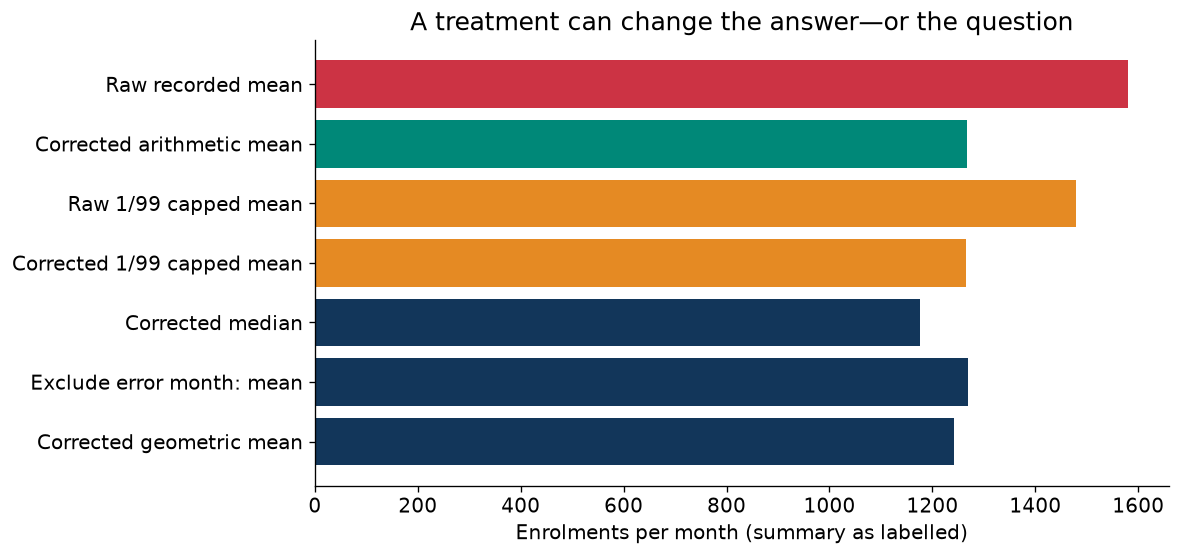

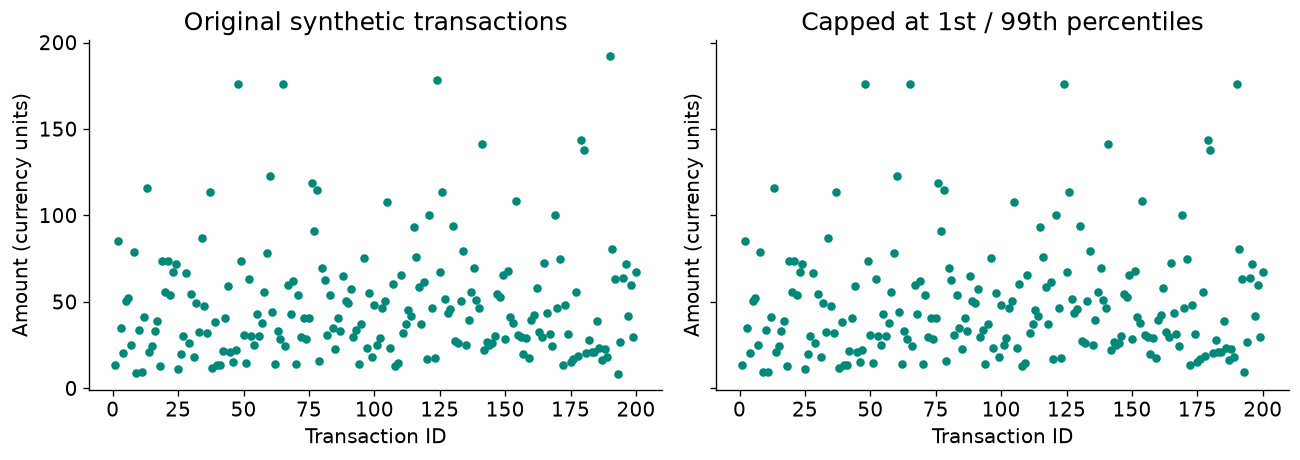

In [9]:
def cap(x,p=.01):
    a = checked(x)
    lo,hi = np.quantile(a,[p,1-p],method='linear')
    return np.clip(a,lo,hi),lo,hi

raw_capped,raw_lo,raw_hi = cap(analysis.observed)
corrected_capped,cap_lo,cap_hi = cap(analysis.corrected)
comparison = pd.DataFrame([
    ['Raw recorded mean',36,analysis.observed.mean(),'Includes verified error'],
    ['Corrected arithmetic mean',36,analysis.corrected.mean(),'Mean of verified monthly counts'],
    ['Raw 1/99 capped mean',36,raw_capped.mean(),'Capping does not repair the source error'],
    ['Corrected 1/99 capped mean',36,corrected_capped.mean(),'Modified-data mean; valid extremes altered'],
    ['Corrected median',36,analysis.corrected.median(),'Middle month; different summary'],
    ['Exclude error month: mean',35,analysis.loc[~has_source,'corrected'].mean(),'Different observation window'],
    ['Corrected geometric mean',36,np.exp(np.log(analysis.corrected).mean()),'Multiplicative summary; different estimand']
],columns=['analysis','months','value','interpretation'])
display(comparison.round(2))
print(f'Corrected-data cap limits: {cap_lo:.2f}, {cap_hi:.2f}; changed months: {(corrected_capped!=analysis.corrected).sum()}')
fig,ax=plt.subplots(figsize=(10,4.8))
ax.barh(comparison.analysis,comparison.value,color=[RED,TEAL,ORANGE,ORANGE,NAVY,NAVY,NAVY])
ax.invert_yaxis(); ax.set(xlabel='Enrolments per month (summary as labelled)',title='A treatment can change the answer—or the question')
fig.tight_layout(); fig.savefig(OUT/'03_treatment_comparison.png'); plt.show()
tx_cap,tx_lo,tx_hi = cap(transactions.amount)
fig,axes=plt.subplots(1,2,figsize=(11,4),sharex=True,sharey=True)
for ax,values,title in zip(axes,[transactions.amount,tx_cap],['Original synthetic transactions','Capped at 1st / 99th percentiles']):
    ax.scatter(transactions.id,values,s=17,color=TEAL)
    ax.set(title=title,xlabel='Transaction ID',ylabel='Amount (currency units)')
fig.tight_layout(); fig.savefig(OUT/'04_winsorization.png'); plt.show()


### What did we learn?
The raw mean is **1,580.36** enrolments/month. Correcting the verified error reduces it to **1,267.86**. Capping the raw data leaves **1,479.57**, so it has not repaired the error. After correction, capping gives **1,265.59**, because it also changes valid extremes. The corrected median is **1,176.50** (the middle month); excluding the recoverable error month gives **1,268.37** over only 35 months. The geometric mean is **1,242.55**, a multiplicative summary. No method is universally best: match the summary and treatment to the question and evidence.

The shared axes show exactly what capping changed. Rows survive, but their observed values do not. Tail risk, totals, estimates and standard errors can change. Ordinary standard-error formulas may also be inappropriate after data-dependent treatment. This lesson compares descriptive summaries; it does not attach inferential confidence intervals to them.

## 8 | Anomaly detection can become surveillance
**Anomaly detection is not only data cleaning. It can be surveillance.**

In monitoring data, a change may merit investigation before its cause is known:

- **Public health:** unexpected rise in cases.
- **Business:** sudden sales decline.
- **Finance:** unusual transaction behaviour.
- **Engineering:** sensor deviation before equipment failure.
- **Supply chain:** unexpected delivery delays.

**Expected value** is what the fitted baseline anticipates for that month. **Observed value** is what was recorded (using the source-corrected count for this analysis). **Residual/deviation = observed − expected**: a positive residual is above expectation; a negative one is below it. “Expected” is a model estimate, not a guarantee or the hidden simulation truth.

A sustained pattern can matter more than one isolated extreme because several consecutive departures suggest a continuing change. It still does not establish the cause, and waiting for persistence delays the first alert.

A one-off campaign spike and six elevated months need different follow-up. Fit a simple baseline using only the **first 24 months**, after source correction and with the documented campaign month excluded from baseline fitting. Freeze that baseline before looking at months 25–36. The campaign remains in the descriptive data.

We model an intercept, linear trend and annual sine/cosine terms. Residual = observed count − expected count. Scale residuals by 1.4826 × baseline MAD; flag an absolute residual beyond 3.5 scales. Three consecutive positive flags trigger an illustrative sustained alert. Baseline-period flags are retrospective diagnostics; only months 25–36 demonstrate prospective application.

These are heuristic bounds, not calibrated prediction intervals. Two seasonal cycles are a small training set. Trend misspecification, autocorrelation, count-dependent variance, reporting delays and repeated testing can affect false alarms. Real deployment needs longer historical evaluation and a response protocol. We use no future months to fit the baseline or scale.


**What are we doing?** Compare each corrected count with a time-specific expected baseline.

**Why does it matter?** An unusual observation may be the first indication that the process itself has changed.

**What should you look for?** Observed counts, the expected line, residual flags and persistence across months.


,date,observed,corrected,expected,residual,robust_residual_score,prospective,anomaly_flag,sustained_alert
23,2024-12-01,2050,2050.0,1177.45,872.55,37.56,False,True,False
30,2025-07-01,1681,1681.0,1316.06,364.94,15.71,True,True,False
31,2025-08-01,1675,1675.0,1257.66,417.34,17.97,True,True,False
32,2025-09-01,1690,1690.0,1219.94,470.06,20.24,True,True,True
33,2025-10-01,1586,1586.0,1216.09,369.91,15.93,True,True,True
34,2025-11-01,1733,1733.0,1250.25,482.75,20.78,True,True,True
35,2025-12-01,1683,1683.0,1316.36,366.64,15.78,True,True,True


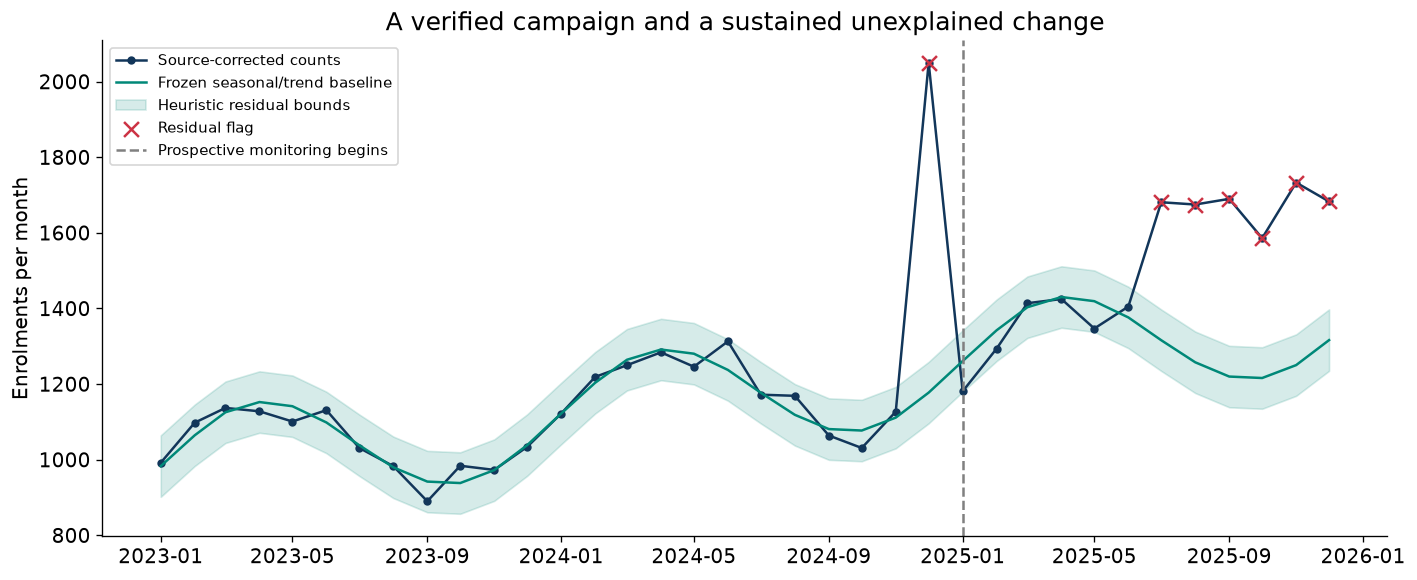

First sustained alert: 2025-09-01 00:00:00
Baseline residual lag-1 correlation (diagnostic only): -0.303


In [10]:
X = np.column_stack([np.ones(36),t,np.sin(2*np.pi*t/12),np.cos(2*np.pi*t/12)])
train = (t<24)&(t!=23)
beta = np.linalg.lstsq(X[train],analysis.corrected.to_numpy()[train],rcond=None)[0]
pred = X@beta
residual = analysis.corrected.to_numpy()-pred
center = np.median(residual[train])
scale = 1.4826022185*np.median(np.abs(residual[train]-center))
assert scale>0
monitor = analysis[['date','observed','corrected']].copy()
monitor['expected'] = pred+center
monitor['residual'] = analysis.corrected-monitor.expected
monitor['robust_residual_score'] = monitor.residual/scale
monitor['prospective'] = t>=24
monitor['anomaly_flag'] = np.abs(monitor.robust_residual_score)>3.5
positive = (monitor.robust_residual_score>3.5)&monitor.prospective
monitor['sustained_alert'] = positive.astype(int).rolling(3,min_periods=3).sum().eq(3)
display(monitor.loc[monitor.anomaly_flag|monitor.sustained_alert].round({c:2 for c in monitor.select_dtypes('number').columns}))
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(monitor.date,monitor.corrected,'-o',color=NAVY,markersize=4,label='Source-corrected counts')
ax.plot(monitor.date,monitor.expected,color=TEAL,label='Frozen seasonal/trend baseline')
ax.fill_between(monitor.date,monitor.expected-3.5*scale,monitor.expected+3.5*scale,color=TEAL,alpha=.16,label='Heuristic residual bounds')
ax.scatter(monitor.loc[monitor.anomaly_flag,'date'],monitor.loc[monitor.anomaly_flag,'corrected'],color=RED,marker='x',s=80,label='Residual flag',zorder=5)
ax.axvline(monitor.date.iloc[24],color='gray',linestyle='--',label='Prospective monitoring begins')
ax.set(ylabel='Enrolments per month',title='A verified campaign and a sustained unexplained change')
ax.legend(fontsize=9,loc='upper left'); fig.tight_layout()
fig.savefig(OUT/'05_anomaly_monitoring.png'); plt.show()
print('First sustained alert:',monitor.loc[monitor.sustained_alert,'date'].min())
print('Baseline residual lag-1 correlation (diagnostic only):',round(pd.Series(residual[train]).autocorr(),3))


### What did we learn?
**The first sustained alert is September 2025.** July, August and September are three consecutive positive residual flags. The next cell displays the exact September comparison to connect the global and contextual rules.

The chart separates the campaign from the later sustained elevation. An alert should initiate verification and investigation; it does not identify an outbreak, fraud or equipment failure by itself. Check denominators, measurement changes and reporting completeness. A rising series can be a genuine trend, a new reporting system or a substantive event.



In [11]:
context_example=monitor.loc[[32],['date','corrected','expected','residual','robust_residual_score','sustained_alert']].copy()
context_example['global_iqr_flag']=bool(flags[32])
display(context_example.round({column: 2 for column in context_example.select_dtypes(include='number').columns}))
context_example.to_csv(OUT/'anomaly_manifest_v2_context.csv',index=False,float_format='%.10g')
assert not flags[32] and monitor.sustained_alert.iloc[32]


,date,corrected,expected,residual,robust_residual_score,sustained_alert,global_iqr_flag
32,2025-09-01,1690.0,1219.94,470.06,20.24,True,False


### What did we learn?
In **September 2025**, the corrected observed count is **1,690**, the expected count is **1,219.94**, and the positive residual is **470.06** enrolments. That is the precise result behind the rounded “1,700 versus 1,200” example. It is **not globally IQR-flagged**, yet it contributes to a **sustained contextual alert**.

The global rule asks where a value lies among all 36 months. The monitoring rule asks whether it fits this month's expected behaviour. An unflagged global value can still deserve investigation.
## 9 | Stress-test the conclusion
Change the residual multiplier while holding the data, corrected values, baseline, scale and three-month persistence rule fixed. Then change the capping percentile while holding the data and descriptive question fixed. These are **sensitivity scenarios**, not probabilistic uncertainty intervals.


**What are we doing?** Change thresholds while keeping the data and model fixed.

**Why does it matter?** An alert should not depend entirely on one arbitrary cutoff.

**What should you look for?** Whether a sustained warning remains at 2.5, 3.5 and 4.5 residual scales, and whether its first date changes.


In [12]:
sensitivity_rows=[]
for k in [2.5,3.5,4.5]:
    pos = (monitor.robust_residual_score>k)&monitor.prospective
    alerts = pos.astype(int).rolling(3,min_periods=3).sum().eq(3)
    first = monitor.loc[alerts,'date'].min()
    sensitivity_rows.append({'multiplier':k,'prospective_flags':int(((np.abs(monitor.robust_residual_score)>k)&monitor.prospective).sum()),
                             'sustained_alert_months':int(alerts.sum()),'first_sustained_alert':str(first.date()) if pd.notna(first) else 'None'})
sensitivity=pd.DataFrame(sensitivity_rows)
display(sensitivity)
cap_sensitivity=[]
for p in [0,.01,.025,.05]:
    values,lo,hi=cap(analysis.corrected,p)
    cap_sensitivity.append({'tail_fraction':p,'mean':values.mean(),'changed_months':int((values!=analysis.corrected).sum()),
                            'difference_from_corrected_mean':values.mean()-analysis.corrected.mean()})
cap_sensitivity=pd.DataFrame(cap_sensitivity)
display(cap_sensitivity.round(2))
print('Sustained increase survives all tested thresholds:',(sensitivity.sustained_alert_months>0).all())


,multiplier,prospective_flags,sustained_alert_months,first_sustained_alert
0,2.5,8,4,2025-09-01
1,3.5,6,4,2025-09-01
2,4.5,6,4,2025-09-01


,tail_fraction,mean,changed_months,difference_from_corrected_mean
0,0.00,1267.86,0,0.00
1,0.01,1265.59,2,-2.28
2,0.02,1262.17,2,-5.69
3,0.05,1259.99,4,-7.88


Sustained increase survives all tested thresholds: True


### What did we learn?
All three tested multipliers retain the sustained warning, with the same first alert in **September 2025** and **four sustained-alert months**. At 2.5, there are **eight** prospective point flags, compared with **six** at 3.5 and 4.5. Point flags and sustained alerts are different counts.

Persistence across several reasonable thresholds increases our confidence that the pattern deserves investigation. It does **not** prove causality or validate the model.

A conclusion that survives these thresholds is stable to this particular choice, not to every model assumption. Capping can suppress real demand when the largest months are valid. If the operational question is resource demand, that loss is substantive.

### Experiment: how large must the sustained change be?
Vary only the injected increase in the final six months. Hold the exact simulated noise, seasonality, trend, fitted baseline and threshold fixed. This is one controlled teaching realization, not an estimate of detection power. Power and false-alarm rates would require many replications and independent validation.


**What are we doing?** Vary only the added increase during the final six months.

**Why does it matter?** This separates the effect of signal size from changes in the noise or baseline.

**What should you look for?** How many final months are flagged and how often the three-month persistence condition is satisfied.


,injected_increase,flagged_final_months,sustained_alert_months
0,0,0,0
1,50,2,0
2,100,3,0
3,200,6,4
4,420,6,4


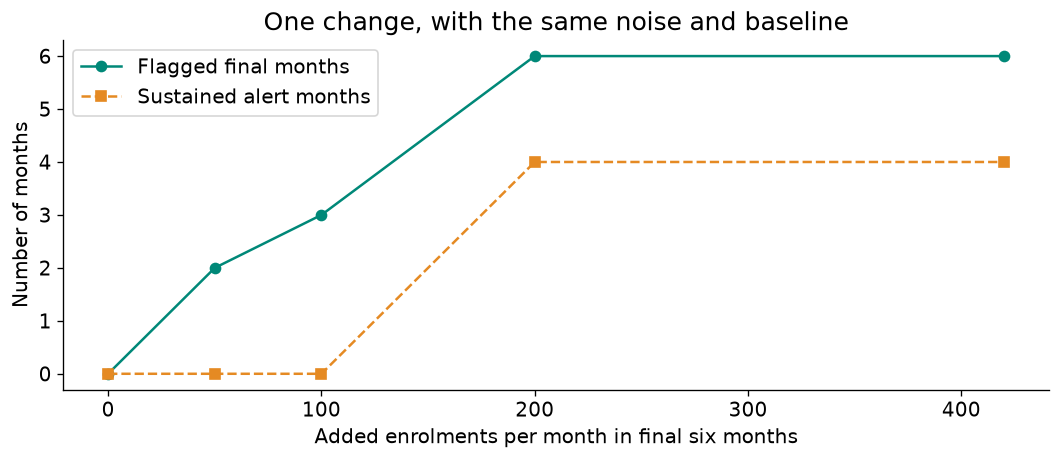

In [13]:
experiment_rows=[]
for increase in [0,50,100,200,420]:
    scenario=analysis.corrected.to_numpy().copy()
    scenario[30:]=scenario[30:]-420+increase
    score=(scenario-monitor.expected.to_numpy())/scale
    pos=(score>3.5)&(t>=24)
    alert=pd.Series(pos.astype(int)).rolling(3,min_periods=3).sum().eq(3)
    experiment_rows.append({'injected_increase':increase,'flagged_final_months':int((score[30:]>3.5).sum()),
                            'sustained_alert_months':int(alert.sum())})
experiment=pd.DataFrame(experiment_rows)
display(experiment)
fig,ax=plt.subplots(figsize=(9,4))
ax.plot(experiment.injected_increase,experiment.flagged_final_months,'o-',color=TEAL,label='Flagged final months')
ax.plot(experiment.injected_increase,experiment.sustained_alert_months,'s--',color=ORANGE,label='Sustained alert months')
ax.set(xlabel='Added enrolments per month in final six months',ylabel='Number of months',yticks=range(7),title='One change, with the same noise and baseline')
ax.legend();fig.tight_layout();fig.savefig(OUT/'06_controlled_experiment.png');plt.show()


### What did we learn?
The persistence rule waits for evidence across months, so it trades speed for stability. Small changes may not trigger it. In real systems, decide in advance how quickly an alert must be investigated and what false-alarm burden is acceptable.

## 10 | Use the evidence to choose an action
**DETECT → VERIFY → CONTEXTUALIZE → QUANTIFY → DECIDE → STRESS-TEST → MONITOR**

| Evidence | Action | Record |
|---|---|---|
| Confirmed entry/unit error | Correct from source | Original, corrected value, evidence, date and reviewer |
| Verified rare event | Usually retain | Event context and analytical purpose |
| Valid but influential values | Consider robust summary/model, transformation, stratification | Estimand and sensitivity results |
| Proposed winsorization | Require a purpose and prespecified rationale | Cutoffs, changed records and uncapped result |
| Ineligible or irrecoverably invalid record | Exclude only with a defensible reason | Eligibility rule, impact and audit trail |
| Unexplained contextual pattern | Investigate and monitor | Baseline, trigger, follow-up owner and resolution |

The example error is recoverable, so excluding it wastes information. A campaign indicator can help a model distinguish a known intervention from the routine baseline. A log transform may suit multiplicative variation in positive data, but changes interpretation and does not repair incorrect values.

### Same investigation logic, different sectors
Public health: rising cases require population/testing context. Business: a sales spike requires campaign and transaction checks. Finance: unusual amount/frequency requires account context. Engineering: sensor shifts require calibration and operating conditions. Cybersecurity: login patterns require device and user context. Supply chains: delays require route, stock and demand context. None of these examples establishes a validated detector for that sector.

### Evidence behind the methods
[NIST's outlier guidance](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm) distinguishes identifying candidates from deciding how to accommodate them and describes modified z-scores. [NIST's boxplot guidance](https://www.itl.nist.gov/div898/handbook/eda/section3/boxplot.htm) explains fences and whiskers. [SciPy's MAD documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.median_abs_deviation.html) documents robust scale. [SciPy's trimming/winsorization guide](https://docs.scipy.org/doc/scipy/tutorial/stats/outliers.html) explains implementation choices. Our synthetic exercise illustrates methods; it is not a replication of a published study.

### Try it yourself
1. Change the IQR multiplier to 3. Which records remain flagged, and what evidence would justify action?
2. Explain why a median and an arithmetic mean answer different questions about monthly demand.
3. Remove the campaign exclusion from baseline fitting. How do the baseline and future flags change?
4. Describe two reporting changes that could mimic the sustained signal. What data would distinguish them?
5. Evaluate the detector on repeated synthetic series before claiming a false-alarm rate.

### A final decision aid
**UNUSUAL VALUE DETECTED**  
↓  
**Can you verify a data error?**  
**YES → Correct it.** Preserve the original and document the correction.  
**NO ↓**  
**Is it a valid documented event?**  
**YES → Keep it.** Add context and model appropriately.  
**NO ↓**  
**Is it influential but plausibly valid?**  
**YES → Consider robust methods + sensitivity analysis.**  
↓ Continue checking time and context, whether or not it is influential.  
**Is it unusual relative to time/context?**  
**YES → Investigate + monitor.**  
↓  
**Still uncertain? → Preserve it, document uncertainty, and investigate further.**

These checks can overlap: a verified event can still need monitoring, and robust analysis does not replace investigation.

> **Never delete an observation solely because an algorithm called it an outlier.**

### Keep the analysis and its audit trail
The next cell writes CSV tables, the raw synthetic datasets, treatment log, model parameters, package versions and seven chart files (the original six plus the boxplot anatomy visual) to `outputs/`. In Colab, use the Files pane to download them. The original recorded values remain intact.


**What are we doing?** Choose a documented action and export the evidence.

**Why does it matter?** Data cleaning should be auditable; correction must not erase the history of what was observed.

**What should you look for?** Original and corrected values, reasons, actions and the synthetic source indicator in the treatment log.


In [14]:
decisions=investigation[['date','observed','source_verified','reason','action']].copy()
decisions['iqr_flag']=flags
decisions['residual_flag']=monitor.anomaly_flag
decisions['sustained_alert']=monitor.sustained_alert
exports={
 'simulated_outlier_anomaly_data.csv':raw.merge(evidence,on='date'),
 'synthetic_transactions.csv':transactions,
 'five_number_summary.csv':five_number.reset_index(names='statistic'),
 'iqr_flags.csv':flag_table,
 'robust_statistics.csv':robust_comparison,
 'outlier_scores.csv':scores,
 'treatment_comparison.csv':comparison,
 'treatment_log.csv':treatment_log,
 'anomaly_monitoring.csv':monitor,
 'treatment_decisions.csv':decisions,
 'flagged_observations_with_actions.csv':decisions.loc[decisions.iqr_flag|decisions.residual_flag|decisions.sustained_alert],
 'threshold_sensitivity.csv':sensitivity,
 'cap_sensitivity.csv':cap_sensitivity,
 'controlled_experiment.csv':experiment,
 'winsorized_transactions.csv':transactions.assign(capped_amount=tx_cap)
}
for name,table in exports.items(): table.to_csv(OUT/name,index=False,float_format='%.10g')
pd.testing.assert_frame_equal(raw,raw_snapshot)
assert flags[14] and monitor.anomaly_flag.iloc[23]
assert monitor.sustained_alert.iloc[32:].all()
assert not monitor.sustained_alert.iloc[:30].any()
assert len(corrected_capped)==len(raw)
assert np.isclose(np.quantile(enrolments,.75)-np.quantile(enrolments,.25),iqr)
assert np.isnan(robust_z([1,1,1,1])).all()
assert iqr_screen([1,2,3,4,100])[0][-1]
manifest={'seed':SEED,'months':len(raw),'transactions':len(transactions),
 'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,'matplotlib':matplotlib.__version__,
 'quartile_method':'linear','model_coefficients':beta.tolist(),'baseline_residual_scale':float(scale),
 'training_month_indices':np.flatnonzero(train).tolist(),'training_uses_future':False,
 'small_example_fences':{'lower':float(lower),'upper':float(upper)},
 'corrected_mean':float(analysis.corrected.mean()),'raw_mean':float(analysis.observed.mean()),
 'first_sustained_alert':str(monitor.loc[monitor.sustained_alert,'date'].min().date()),
 'checks':'All assertions passed','output_files':sorted(list(exports) + ['01_enrolment_example.png','02_four_views.png','03_treatment_comparison.png','04_winsorization.png','05_anomaly_monitoring.png','06_controlled_experiment.png','07_boxplot_anatomy.png','anomaly_manifest_v2_context.csv','analysis_manifest.json'])}
(OUT/'analysis_manifest.json').write_text(json.dumps(manifest,indent=2))
print(json.dumps(manifest,indent=2))


{
  "seed": 20261002,
  "months": 36,
  "transactions": 200,
  "python": "3.12.14",
  "numpy": "2.5.3",
  "pandas": "3.0.6",
  "matplotlib": "3.11.2",
  "quartile_method": "linear",
  "model_coefficients": [
    977.6309464961947,
    11.57612443985837,
    141.854413224177,
    7.157364300913373
  ],
  "baseline_residual_scale": 23.227874461148932,
  "training_month_indices": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22
  ],
  "training_uses_future": false,
  "small_example_fences": {
    "lower": 168.125,
    "upper": 463.125
  },
  "corrected_mean": 1267.861111111111,
  "raw_mean": 1580.361111111111,
  "first_sustained_alert": "2025-09-01",
  "checks": "All assertions passed",
  "output_files": [
    "01_enrolment_example.png",
    "02_four_views.png",
    "03_treatment_comparison.png",
    "04_winsorization.png",
    "05_anomaly_monitoring.png",
    "06_

### What did we learn?
The exported files preserve the original observations, the verified correction, screening flags, treatment comparisons and monitoring results. The synthetic `decision_basis` identifies the source as fictional teaching evidence; the date in the log is the observation month, not an invented real-world review timestamp.

### Five final takeaways
1. **An outlier is not automatically an error.**
2. **IQR detects unusual values. It does not tell you what caused them.**
3. **Valid extremes may contain important information.**
4. **Contextual anomalies can provide early-warning signals even when they are not global outliers.**
5. **Detect → Verify → Understand → Decide → Monitor.**

Do not ask only: **“Is this value unusual?”**  
Ask: **“Why is it unusual, and what does it mean?”**

**An unusual value is a question to investigate, not an instruction to delete.**

**EvidenceLab | See it. Understand it. Run it.**
